In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
df = pd.read_csv('SampleSuperstore.csv')

df.head()

,Order ID,Order Date,Ship Mode,Customer Name,Segment,Region,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2023-1001,04/01/2024,Standard Class,Darrell Harding,Consumer,West,Technology,Monitor,Monitor Scene,807.97,7,0.27,-44.37
1,CA-2024-1002,01/26/2023,Second Class,Norma Perry,Consumer,Central,Furniture,Table,Table Education,974.58,4,0.28,188.97
2,CA-2023-1003,05/12/2024,First Class,Michael Cohen,Home Office,West,Furniture,Chair,Chair Both,913.06,2,0.40,271.24
3,CA-2024-1004,12/02/2023,Standard Class,Dana Stout,Consumer,Central,Technology,Printer,Printer Public,167.92,10,0.48,75.84
4,CA-2025-1005,08/09/2024,Standard Class,Gary Patterson,Home Office,Central,Technology,Monitor,Monitor Would,414.43,4,0.12,257.29


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       1000 non-null   object 
 1   Order Date     1000 non-null   object 
 2   Ship Mode      1000 non-null   object 
 3   Customer Name  1000 non-null   object 
 4   Segment        1000 non-null   object 
 5   Region         1000 non-null   object 
 6   Category       1000 non-null   object 
 7   Sub-Category   1000 non-null   object 
 8   Product Name   1000 non-null   object 
 9   Sales          1000 non-null   float64
 10  Quantity       1000 non-null   int64  
 11  Discount       1000 non-null   float64
 12  Profit         1000 non-null   float64
dtypes: float64(3), int64(1), object(9)
memory usage: 101.7+ KB


In [ ]:
df.describe()

,Sales,Quantity,Discount,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,509.727200,5.532000,0.245780,125.507920
std,280.359458,2.963741,0.143612,101.986209
min,21.240000,1.000000,0.000000,-49.880000
25%,278.372500,3.000000,0.120000,41.100000
50%,506.840000,6.000000,0.240000,122.405000
75%,754.510000,8.000000,0.370000,212.445000
max,998.240000,10.000000,0.500000,299.630000


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Mode,0
Customer Name,0
Segment,0
Region,0
Category,0
Sub-Category,0
Product Name,0
Sales,0


In [ ]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 509727.2


In [ ]:
total_profit = df['Profit'].sum()
print("Total Profit:", total_profit)

Total Profit: 125507.92


In [ ]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 1000


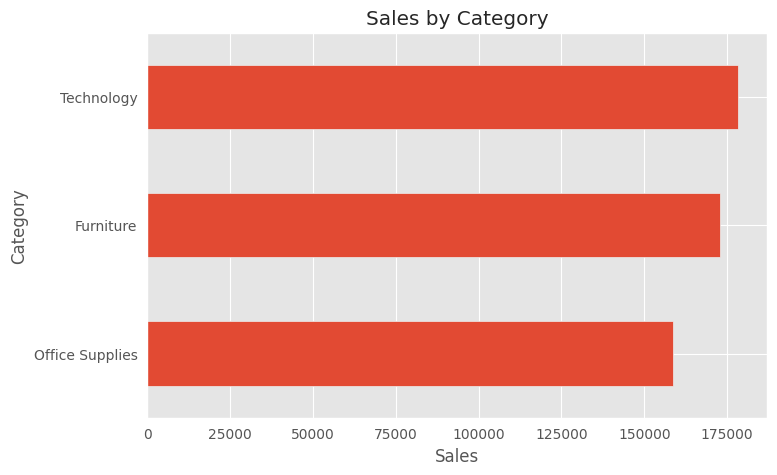

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='barh', figsize=(8,5))

plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')

plt.show()

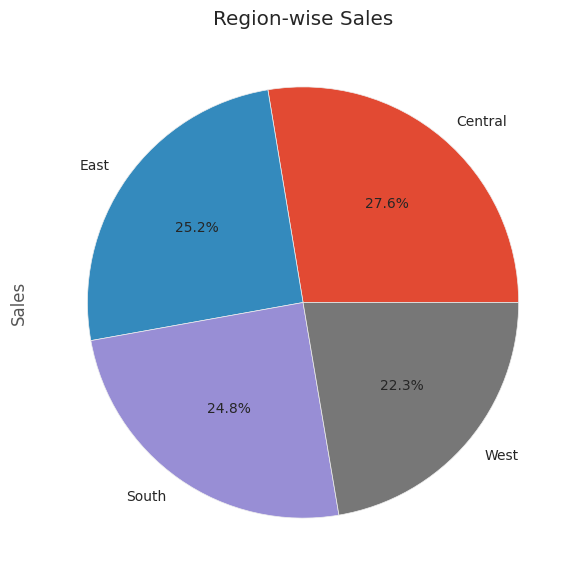

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7))

plt.title('Region-wise Sales')

plt.show()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [ ]:
df['Month'] = df['Order Date'].dt.month

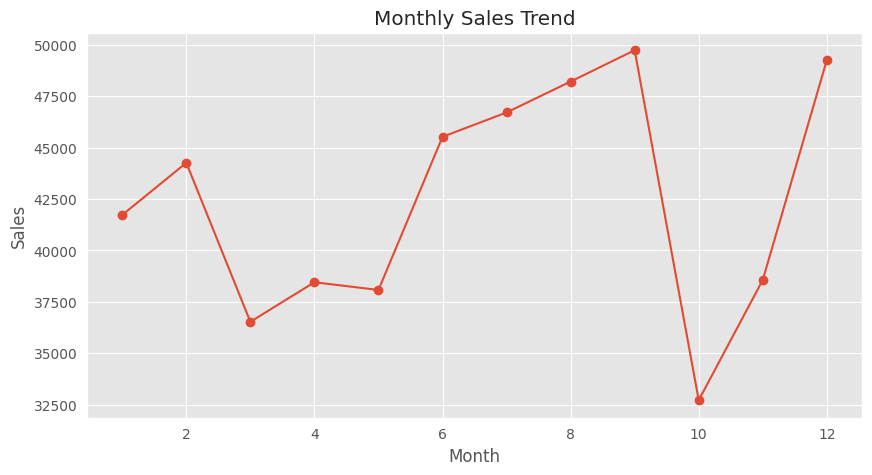

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(marker='o', figsize=(10,5))

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.show()

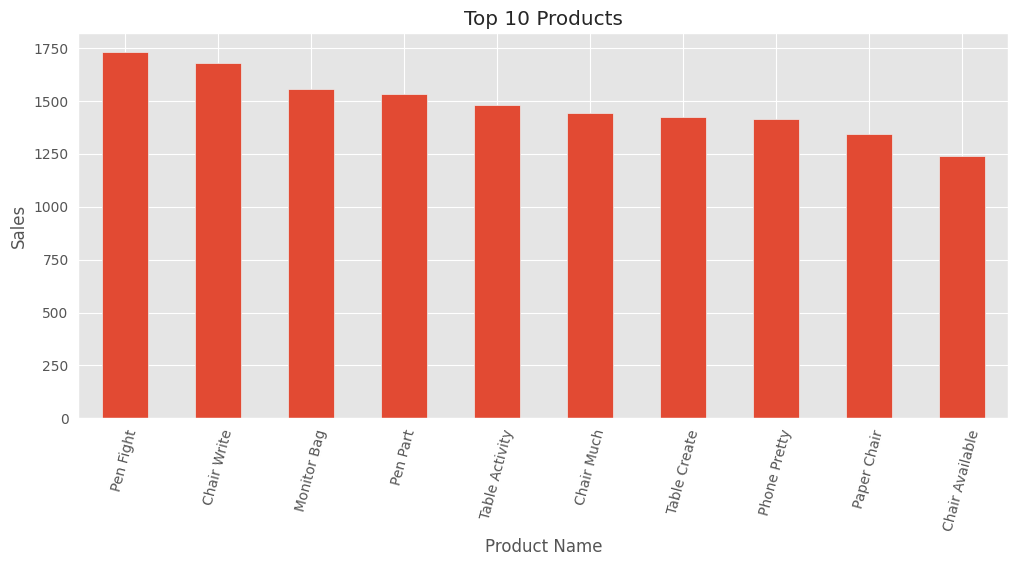

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(12,5))

plt.title('Top 10 Products')
plt.ylabel('Sales')

plt.xticks(rotation=75)

plt.show()

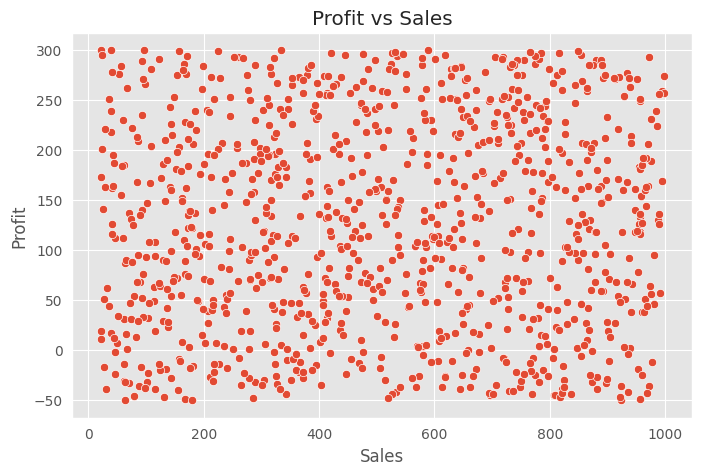

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title('Profit vs Sales')

plt.show()

In [ ]:
df.to_csv('cleaned_superstore.csv', index=False)